In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../prompt_testing/sheets/gpt_vs_sabia_p1-5.csv", decimal=",")

# calcula RMSE por grupo
rmse_df = df.groupby(["llm", "prompt", "temp", "essay"]).apply(
    lambda g: np.sqrt(np.mean((g["eval-ai"] - g["eval-human"])**2))
).reset_index(name="rmse")

rmse_df

/var/folders/v3/2l7xjvsd26j3s4vzjl7mfpp40000gn/T/ipykernel_57147/1031838478.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_df = df.groupby(["llm", "prompt", "temp", "essay"]).apply(


,llm,prompt,temp,essay,rmse
0,gpt,1,0.0,1,1.60
1,gpt,1,0.0,2,1.50
2,gpt,1,0.0,3,3.83
3,gpt,1,0.0,4,3.37
4,gpt,1,0.0,5,2.47
...,...,...,...,...,...
175,sabia,5,0.9,2,0.30
176,sabia,5,0.9,3,2.43
177,sabia,5,0.9,4,10.87
178,sabia,5,0.9,5,1.73


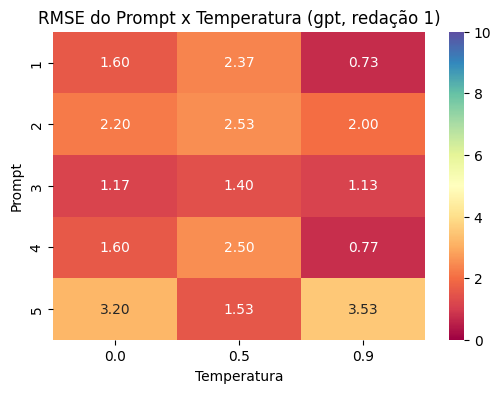

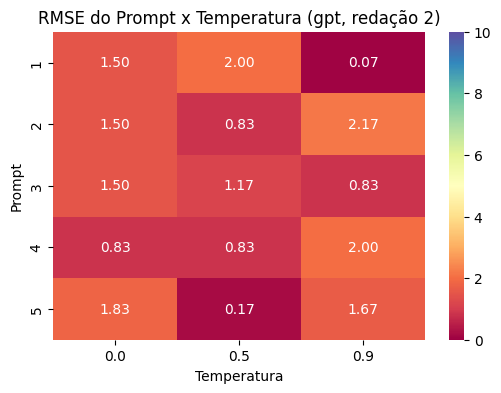

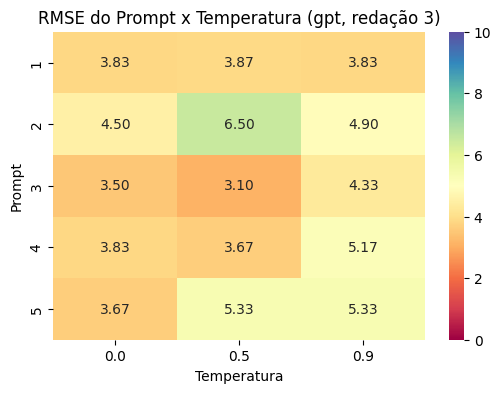

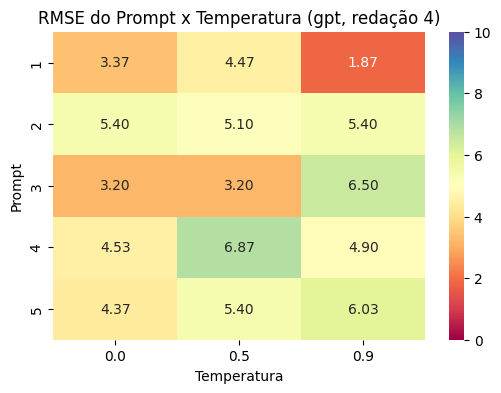

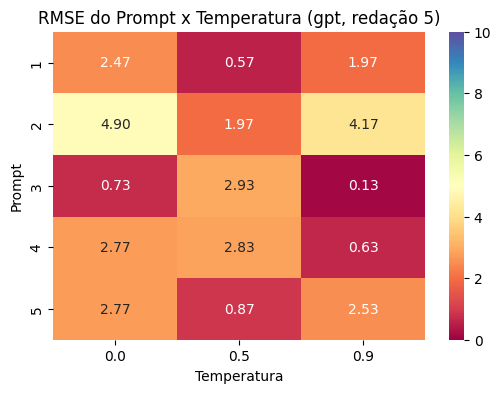

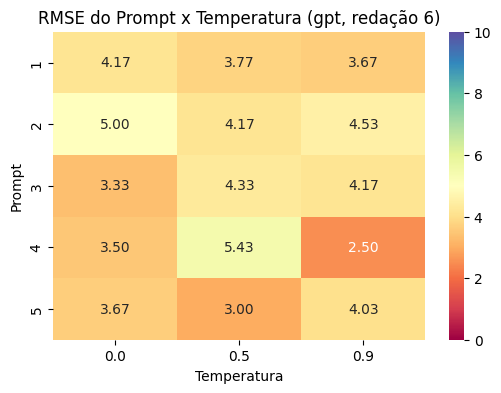

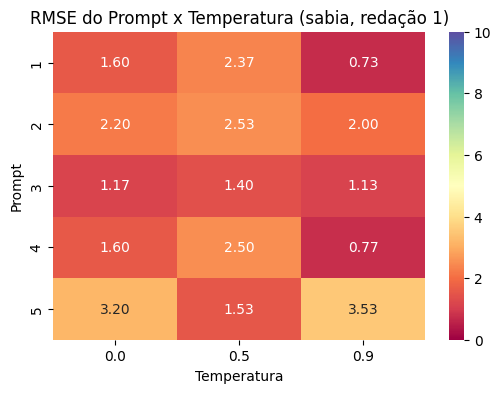

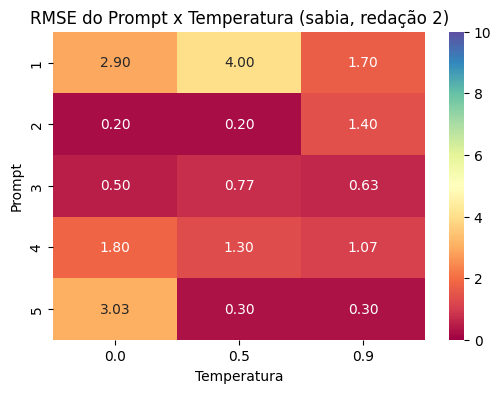

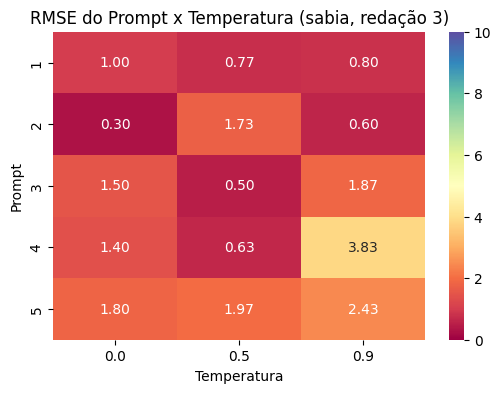

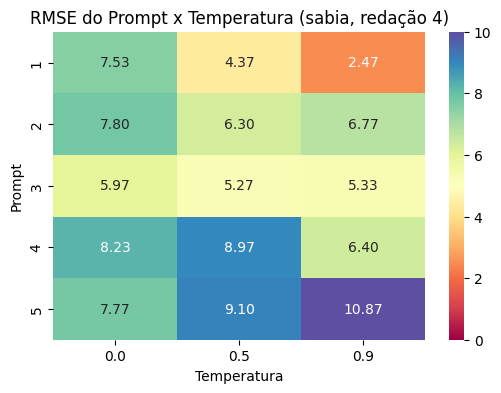

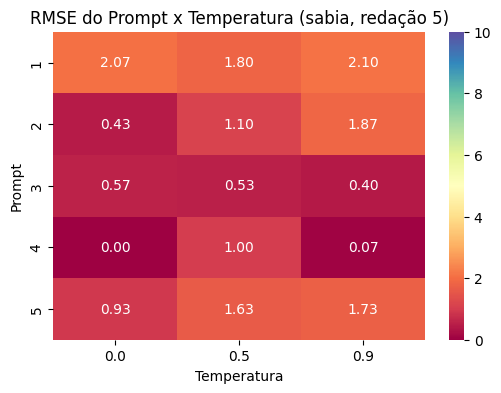

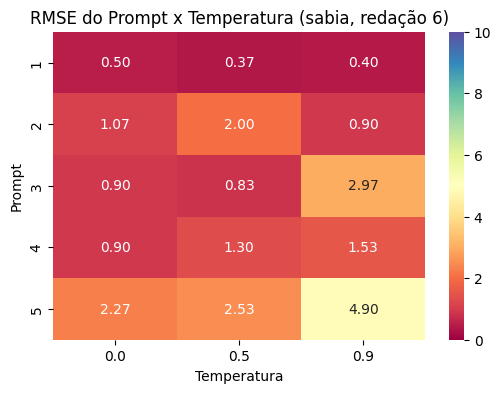

In [26]:
# Cria um heatmap para cada LLM e redação

for llm in rmse_df["llm"].unique():
    llm_subset = rmse_df[rmse_df["llm"] == llm]
    for essay in rmse_df["essay"].unique():
        essay_subset = llm_subset[llm_subset["essay"] == essay]

        pivot = essay_subset.pivot(index="prompt", columns="temp", values="rmse")

        plt.figure(figsize=(6,4))
        sns.heatmap(pivot, annot=True, cmap="Spectral", fmt=".2f", vmin=0, vmax=10)
        plt.title(f"RMSE do Prompt x Temperatura ({llm}, redação {essay})")
        plt.ylabel("Prompt")
        plt.xlabel("Temperatura")
        plt.savefig(f"../prompt_testing/heatmaps/heatmap_{llm}_essay{essay}.png", dpi=300)